# CFG88_01_word_unigram_tight — Focused run

Runs a single configuration with threshold tuning like tfidf_stacking_target88.ipynb and adds confusion matrices for validation and test.

In [1]:
import json
import re
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path('data')
LOG_PATH = Path('experiment_log_target88.md')
LEADERBOARD_PATH = Path('leaderboard_cfg88_01.csv')
SAVE_THRESHOLD = 0.80
TARGET_ACCURACY = 0.88

print('Data dir:', DATA_DIR.resolve())
print('Target accuracy:', TARGET_ACCURACY)

Data dir: /Users/hoangvinh/Library/CloudStorage/OneDrive-Personal/Workspace/TF-IDF_vuln_detect/data
Target accuracy: 0.88


In [2]:
REQUIRED_COLUMNS = ['idx', 'func', 'target']

def load_split(split_name: str, data_dir: Path) -> pd.DataFrame:
    csv_path = data_dir / f'{split_name}.csv'
    jsonl_path = data_dir / f'{split_name}.jsonl'
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        source_path = csv_path
    elif jsonl_path.exists():
        df = pd.read_json(jsonl_path, lines=True)
        source_path = jsonl_path
    else:
        raise FileNotFoundError(f'Cannot find {split_name}.csv or {split_name}.jsonl inside {data_dir}')

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f'{source_path} is missing required columns: {missing}')

    df = df[REQUIRED_COLUMNS].copy()
    df['func'] = df['func'].fillna('').astype(str)
    df['target'] = pd.to_numeric(df['target'], errors='coerce')
    df = df.dropna(subset=['target'])
    df['target'] = df['target'].astype(int)

    invalid = sorted(set(df['target'].unique()) - {0, 1})
    if invalid:
        raise ValueError(f'{source_path} has invalid labels: {invalid}')

    print(f'Loaded {source_path.name}: {df.shape}')
    return df

train_df = load_split('train', DATA_DIR)
val_df = load_split('val', DATA_DIR)
test_df = load_split('test', DATA_DIR)

print('Train label ratio:')
display(train_df['target'].value_counts(normalize=True).rename('ratio').to_frame())

Loaded train.jsonl: (4242, 3)
Loaded val.jsonl: (530, 3)
Loaded test.jsonl: (532, 3)
Train label ratio:


,ratio
target,
1,0.5
0,0.5


In [3]:
SUSPICIOUS_TOKENS = ('import', 'exec', 'eval', 'subprocess', 'os.system', 'socket', 'base64', 'urllib', 'requests', 'powershell', 'cmd', 'pip install')

def normalize_code(text: str) -> str:
    text = text.replace('\r\n', '\n').replace('\r', '\n')
    text = re.sub(r'[ \t]+', ' ', text).strip()
    lowered = text.lower()
    if any(token in lowered for token in SUSPICIOUS_TOKENS):
        return lowered
    return text

for frame in (train_df, val_df, test_df):
    frame['func_norm'] = frame['func'].map(normalize_code)

X_train, y_train = train_df['func_norm'], train_df['target']
X_val, y_val = val_df['func_norm'], val_df['target']
X_test, y_test = test_df['func_norm'], test_df['target']

print('Normalization completed. Samples:', len(X_train))

Normalization completed. Samples: 4242


In [4]:
CFG = {
    'id': 'CFG88_01_word_unigram_tight',
    'tfidf': {
        'analyzer': 'word',
        'token_pattern': '(?u)\\b[\\w_]{2,}\\b',
        'max_features': 4000,
        'ngram_range': (1, 1),
        'min_df': 8,
        'max_df': 0.92,
        'sublinear_tf': False,
    },
    'base_builder': lambda: [
        ('lr', LogisticRegression(C=0.45, solver='liblinear', max_iter=2500, random_state=RANDOM_STATE)),
        ('nb', MultinomialNB(alpha=1.2)),
        ('sgd', SGDClassifier(loss='log_loss', alpha=8e-4, max_iter=2500, random_state=RANDOM_STATE)),
    ],
    'meta_builder': lambda: LogisticRegression(C=0.40, solver='liblinear', max_iter=2500, random_state=RANDOM_STATE),
    'rationale': 'Unigram + small vocabulary to keep a stable baseline without overfitting.',
}

print('Loaded config:', CFG['id'])

Loaded config: CFG88_01_word_unigram_tight


In [5]:
def build_pipeline(cfg: dict) -> Pipeline:
    stacking = StackingClassifier(
        estimators=cfg['base_builder'](),
        final_estimator=cfg['meta_builder'](),
        cv=5,
        n_jobs=1,
        stack_method='auto',
        passthrough=False,
    )
    return Pipeline([('tfidf', TfidfVectorizer(**cfg['tfidf'])), ('clf', stacking)])

def architecture_text(cfg: dict):
    base_estimators = cfg['base_builder']()
    base_names = [f"{name}:{est.__class__.__name__}" for name, est in base_estimators]
    meta_name = cfg['meta_builder']().__class__.__name__
    return base_names, meta_name

pipeline = build_pipeline(CFG)

In [6]:
def compute_metrics(y_true, y_pred) -> dict:
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }

def print_metrics(title: str, metrics: dict) -> None:
    print(f"{title}: Acc={metrics['accuracy']:.4f} | Prec={metrics['precision']:.4f} | Rec={metrics['recall']:.4f} | F1={metrics['f1']:.4f}")

def _predict_scores(model: Pipeline, X_text: pd.Series):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_text)[:, 1]
    if hasattr(model, 'decision_function'):
        raw_scores = np.asarray(model.decision_function(X_text), dtype=float)
        min_score, max_score = raw_scores.min(), raw_scores.max()
        if max_score - min_score < 1e-12:
            return np.full(raw_scores.shape[0], 0.5)
        return (raw_scores - min_score) / (max_score - min_score)
    return None

def tune_threshold_to_target(model: Pipeline, X_text: pd.Series, y_true: pd.Series, target_acc: float = TARGET_ACCURACY):
    scores = _predict_scores(model, X_text)
    default_pred = model.predict(X_text)
    default_metrics = compute_metrics(y_true, default_pred)
    if scores is None:
        return {
            'selected_mode': 'predict',
            'selected_threshold': 0.50,
            'selected_pred': default_pred,
            'selected_metrics': default_metrics,
            'default_metrics': default_metrics,
            'tuned_metrics': default_metrics,
        }
    best = None
    for threshold in np.linspace(0.05, 0.95, 181):
        pred = (scores >= threshold).astype(int)
        metrics = compute_metrics(y_true, pred)
        distance = abs(metrics['accuracy'] - target_acc)
        key = (distance, -metrics['f1'])
        if best is None or key < best['key']:
            best = {
                'key': key,
                'threshold': float(threshold),
                'pred': pred,
                'metrics': metrics,
            }
    tuned_distance = abs(best['metrics']['accuracy'] - target_acc)
    default_distance = abs(default_metrics['accuracy'] - target_acc)
    if tuned_distance < default_distance:
        return {
            'selected_mode': 'threshold',
            'selected_threshold': best['threshold'],
            'selected_pred': best['pred'],
            'selected_metrics': best['metrics'],
            'default_metrics': default_metrics,
            'tuned_metrics': best['metrics'],
        }
    return {
        'selected_mode': 'predict',
        'selected_threshold': 0.50,
        'selected_pred': default_pred,
        'selected_metrics': default_metrics,
        'default_metrics': default_metrics,
        'tuned_metrics': best['metrics'],
    }

In [7]:
pipeline.fit(X_train, y_train)

threshold_result = tune_threshold_to_target(pipeline, X_val, y_val, target_acc=TARGET_ACCURACY)
default_metrics = threshold_result['default_metrics']
tuned_metrics = threshold_result['tuned_metrics']
selected_metrics = threshold_result['selected_metrics']
selected_mode = threshold_result['selected_mode']
selected_threshold = threshold_result['selected_threshold']
val_pred = threshold_result['selected_pred']

print_metrics('Validation (default predict)', default_metrics)
print_metrics('Validation (best threshold toward 0.88)', tuned_metrics)
print_metrics('Validation (selected)', selected_metrics)
print(f'Selected mode: {selected_mode} | threshold={selected_threshold:.2f}')

if selected_mode == 'threshold':
    test_scores = _predict_scores(pipeline, X_test)
    if test_scores is None:
        y_test_pred = pipeline.predict(X_test)
    else:
        y_test_pred = (test_scores >= selected_threshold).astype(int)
else:
    y_test_pred = pipeline.predict(X_test)

test_metrics = compute_metrics(y_test, y_test_pred)
print_metrics('Test (train on train)', test_metrics)

Validation (default predict): Acc=0.9717 | Prec=0.9883 | Rec=0.9547 | F1=0.9712
Validation (best threshold toward 0.88): Acc=0.8849 | Prec=0.8129 | Rec=1.0000 | F1=0.8968
Validation (selected): Acc=0.8849 | Prec=0.8129 | Rec=1.0000 | F1=0.8968
Selected mode: threshold | threshold=0.06
Test (train on train): Acc=0.8703 | Prec=0.7940 | Rec=1.0000 | F1=0.8852


Validation confusion matrix:


,Pred_0,Pred_1
Actual_0,204,61
Actual_1,0,265


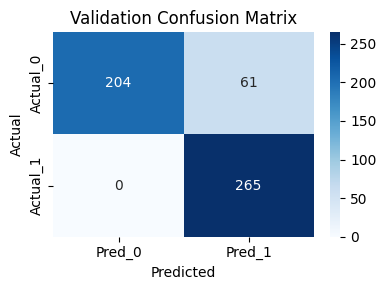

Validation classification report:
              precision    recall  f1-score   support

           0     1.0000    0.7698    0.8699       265
           1     0.8129    1.0000    0.8968       265

    accuracy                         0.8849       530
   macro avg     0.9064    0.8849    0.8834       530
weighted avg     0.9064    0.8849    0.8834       530

Test confusion matrix:


,Pred_0,Pred_1
Actual_0,197,69
Actual_1,0,266


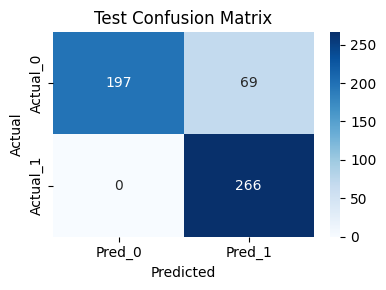

Test classification report:


              precision    recall  f1-score   support

           0     1.0000    0.7406    0.8510       266
           1     0.7940    1.0000    0.8852       266

    accuracy                         0.8703       532
   macro avg     0.8970    0.8703    0.8681       532
weighted avg     0.8970    0.8703    0.8681       532



In [8]:
def show_and_save_confusion(y_true, y_pred, out_path: Path, title: str):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=['Actual_0', 'Actual_1'], columns=['Pred_0', 'Pred_1'])
    display(cm_df)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred_0', 'Pred_1'], yticklabels=['Actual_0', 'Actual_1'])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(str(out_path), dpi=150)
    plt.show()

val_cm_path = Path('cfg88_01_val_confusion.png')
test_cm_path = Path('cfg88_01_test_confusion.png')

print('Validation confusion matrix:')
show_and_save_confusion(y_val, val_pred, val_cm_path, title='Validation Confusion Matrix')
print('Validation classification report:')
print(classification_report(y_val, val_pred, digits=4))

print('Test confusion matrix:')
show_and_save_confusion(y_test, y_test_pred, test_cm_path, title='Test Confusion Matrix')
print('Test classification report:')
print(classification_report(y_test, y_test_pred, digits=4))

In [9]:
def append_log(config_id, tfidf_params, base_models, meta_model, rationale, val_metrics, test_metrics, model_status, model_filename=None, log_path: Path = LOG_PATH):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    tfidf_text = json.dumps(tfidf_params, ensure_ascii=False)
    base_text = ', '.join(base_models)
    if model_filename:
        status_text = f"Saved model `{model_filename}`"
    else:
        status_text = f"Not saved ({model_status})"
    lines = [
        f"## Experiment: {config_id}",
        f"* **Time:** {timestamp}",
        f"* **TF-IDF:** {tfidf_text}",
        f"* **Stacking:** Base = [{base_text}], Meta = [{meta_model}]",
        f"* **Rationale:** {rationale}",
        "",
        "### Validation (train on train):",
        "| Metric | Score |",
        "| :--- | :--- |",
        f"| **Accuracy** | {val_metrics['accuracy'] * 100:.2f}% |",
        f"| **Precision** | {val_metrics['precision']:.3f} |",
        f"| **Recall** | {val_metrics['recall']:.3f} |",
        f"| **F1-Score** | {val_metrics['f1']:.3f} |",
        "",
        "### Test (train on train):",
        "| Metric | Score |",
        "| :--- | :--- |",
        f"| **Accuracy** | {test_metrics['accuracy'] * 100:.2f}% |",
        f"| **Precision** | {test_metrics['precision']:.3f} |",
        f"| **Recall** | {test_metrics['recall']:.3f} |",
        f"| **F1-Score** | {test_metrics['f1']:.3f} |",
        "",
        f"* **Status:** {status_text}",
        "---",
        "",
    ]
    with log_path.open('a', encoding='utf-8') as f:
        f.write("\n".join(lines))

def make_unique_model_filename(acc: float, prefix: str = 'model_tfidf_stacking_acc') -> str:
    base = f"{prefix}{acc * 100:.2f}"
    candidate = Path(f"{base}.joblib")
    counter = 1
    while candidate.exists():
        candidate = Path(f"{base}_v{counter}.joblib")
        counter += 1
    return candidate.name

base_models, meta_model = architecture_text(CFG)
model_filename = None
model_status = f"Validation accuracy < {SAVE_THRESHOLD:.2f}"
if selected_metrics['accuracy'] >= SAVE_THRESHOLD:
    model_filename = make_unique_model_filename(selected_metrics['accuracy'])
    joblib.dump(pipeline, model_filename)
    model_status = 'saved'
    print(f"Saved model: {model_filename}")
else:
    print(f"Validation accuracy < {SAVE_THRESHOLD:.2f} -> skip model saving.")

append_log(
    config_id=CFG['id'],
    tfidf_params=CFG['tfidf'],
    base_models=base_models,
    meta_model=meta_model,
    rationale=f"{CFG['rationale']} | mode={selected_mode}, threshold={selected_threshold:.2f}",
    val_metrics=selected_metrics,
    test_metrics=test_metrics,
    model_status=model_status,
    model_filename=model_filename,
 )

pd.DataFrame([
    {
        'config_id': CFG['id'],
        'val_accuracy': selected_metrics['accuracy'],
        'val_precision': selected_metrics['precision'],
        'val_recall': selected_metrics['recall'],
        'val_f1': selected_metrics['f1'],
        'test_accuracy': test_metrics['accuracy'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_f1': test_metrics['f1'],
        'saved_model': model_filename if model_filename else 'NO',
    }
 ]).to_csv(LEADERBOARD_PATH, index=False)
print(f"Leaderboard saved to: {LEADERBOARD_PATH}")

Saved model: model_tfidf_stacking_acc88.49.joblib


Leaderboard saved to: leaderboard_cfg88_01.csv


Loaded all_data.jsonl: (5304, 3)


All data_full/all_data: Acc=0.8940 | Prec=0.8264 | Rec=0.9977 | F1=0.9040
All-data prediction mode: threshold | threshold=0.06
All data confusion matrix:


,Pred_0,Pred_1
Actual_0,2096,556
Actual_1,6,2646


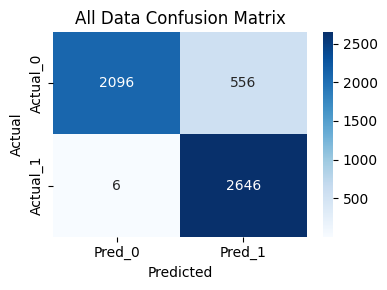

All data classification report:
              precision    recall  f1-score   support

           0     0.9971    0.7903    0.8818      2652
           1     0.8264    0.9977    0.9040      2652

    accuracy                         0.8940      5304
   macro avg     0.9118    0.8940    0.8929      5304
weighted avg     0.9118    0.8940    0.8929      5304

All-data metrics saved to: cfg88_01_all_data_metrics.csv


In [10]:
FULL_DATA_DIR = Path('data_full')
FULL_DATA_FILENAME = 'all_data'
FULL_CM_PATH = Path('cfg88_01_all_data_confusion.png')
FULL_METRICS_PATH = Path('cfg88_01_all_data_metrics.csv')

full_df = load_split(FULL_DATA_FILENAME, FULL_DATA_DIR)
full_df['func_norm'] = full_df['func'].map(normalize_code)
X_full, y_full = full_df['func_norm'], full_df['target']

if selected_mode == 'threshold':
    full_scores = _predict_scores(pipeline, X_full)
    if full_scores is None:
        y_full_pred = pipeline.predict(X_full)
    else:
        y_full_pred = (full_scores >= selected_threshold).astype(int)
else:
    y_full_pred = pipeline.predict(X_full)

full_metrics = compute_metrics(y_full, y_full_pred)
print_metrics('All data_full/all_data', full_metrics)
print(f'All-data prediction mode: {selected_mode} | threshold={selected_threshold:.2f}')

print('All data confusion matrix:')
show_and_save_confusion(y_full, y_full_pred, FULL_CM_PATH, title='All Data Confusion Matrix')
print('All data classification report:')
print(classification_report(y_full, y_full_pred, digits=4))

full_metrics_df = pd.DataFrame([
    {
        'dataset': str(FULL_DATA_DIR / f'{FULL_DATA_FILENAME}.jsonl'),
        'n_samples': len(full_df),
        'accuracy': full_metrics['accuracy'],
        'precision': full_metrics['precision'],
        'recall': full_metrics['recall'],
        'f1': full_metrics['f1'],
        'selected_mode': selected_mode,
        'selected_threshold': selected_threshold,
        'model_file': model_filename if model_filename else 'in_memory_pipeline',
        'confusion_matrix_image': str(FULL_CM_PATH),
    }
])
full_metrics_df.to_csv(FULL_METRICS_PATH, index=False)
print(f'All-data metrics saved to: {FULL_METRICS_PATH}')


## Summary
- Confusion matrices saved: cfg88_01_val_confusion.png, cfg88_01_test_confusion.png, cfg88_01_all_data_confusion.png.
- All-data metrics saved: cfg88_01_all_data_metrics.csv.
- Log appended to experiment_log_target88.md and leaderboard written to leaderboard_cfg88_01.csv.
